# Customer Shopping Behavior — End-to-End Analysis

**Dataset:** 3,900 customer transaction records  
**Tools:** Python (Pandas, Matplotlib, Seaborn), SQL (PostgreSQL)  
**Goal:** Analyze customer revenue patterns, discount impact, seasonal trends, and segment behavior to surface actionable business insights.

---
### Table of Contents
1. Data Loading & Exploration
2. Data Cleaning & Preparation
3. Exploratory Data Analysis (EDA)
4. SQL Analytics
5. Key Business Insights

## 1. Data Loading & Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

In [3]:
df = pd.read_csv('customer_shopping_behavior.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [5]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [6]:
# Check missing values
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

**Observation:** Only `Review Rating` has 37 missing values (~0.9% of data). All other columns are complete.

## 2. Data Cleaning & Preparation

In [7]:
# Fill missing Review Rating with category median (preserves category-level distribution)
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(
    lambda x: x.fillna(x.median())
)
print('Missing values after imputation:')
print(df.isnull().sum())

Missing values after imputation:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


In [8]:
# Standardise column names
df.columns = df.columns.str.lower().str.replace(' ', '_')
df = df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'})
df.columns.tolist()

['customer_id',
 'age',
 'gender',
 'item_purchased',
 'category',
 'purchase_amount',
 'location',
 'size',
 'color',
 'season',
 'review_rating',
 'subscription_status',
 'shipping_type',
 'discount_applied',
 'promo_code_used',
 'previous_purchases',
 'payment_method',
 'frequency_of_purchases']

In [9]:
# Check if discount_applied and promo_code_used are identical columns
identical = (df['discount_applied'] == df['promo_code_used']).all()
print(f'discount_applied == promo_code_used everywhere: {identical}')

# Drop redundant column
df = df.drop('promo_code_used', axis=1)
print('Dropped promo_code_used — duplicate of discount_applied')

discount_applied == promo_code_used everywhere: True
Dropped promo_code_used — duplicate of discount_applied


In [10]:
# Engineer age_group feature using quartile-based bins
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels=labels)

print('Age group distribution:')
print(df['age_group'].value_counts().sort_index())

Age group distribution:
age_group
Young Adult    1028
Adult           942
Middle-aged     986
Senior          944
Name: count, dtype: int64


In [11]:
# Final cleaned dataset
print(f'Final shape: {df.shape}')
df.head()

Final shape: (3900, 18)


,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-aged
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-aged
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-aged


## 3. Exploratory Data Analysis (EDA)

### 3.1 Revenue by Category

FileNotFoundError: [Errno 2] No such file or directory: 'charts/revenue_by_category.png'

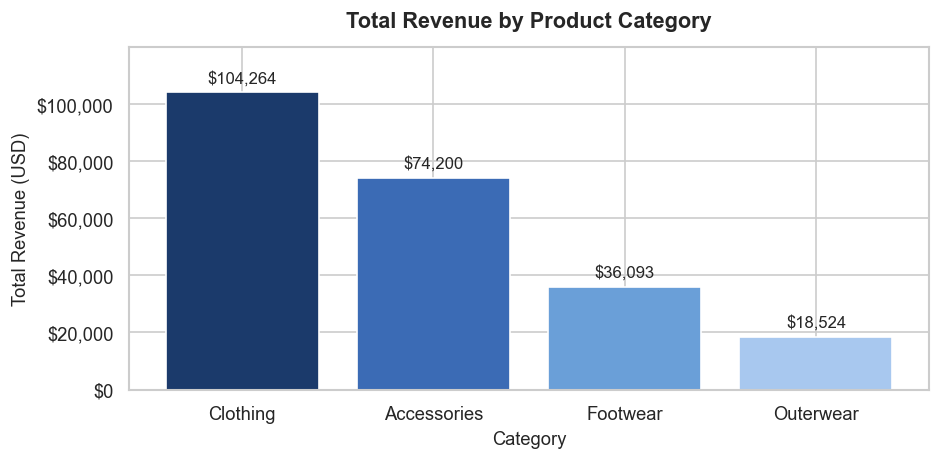

In [12]:
cat_rev = df.groupby('category')['purchase_amount'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cat_rev.index, cat_rev.values, color=['#1B3A6B','#3B6BB5','#6A9FD8','#A8C8EF'])
ax.bar_label(bars, labels=[f'${v:,.0f}' for v in cat_rev.values], padding=4, fontsize=10)
ax.set_title('Total Revenue by Product Category', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Total Revenue (USD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylim(0, cat_rev.max() * 1.15)
plt.tight_layout()
plt.savefig('charts/revenue_by_category.png', bbox_inches='tight')
plt.show()

**Insight:** Clothing drives the majority of revenue at **$104,264 (44.7%)**, followed by Accessories at **$74,200 (31.8%)**. Outerwear contributes the least at $18,524 — however, its average purchase value ($57.17) is the lowest, suggesting a pricing opportunity.

### 3.2 Revenue by Gender

In [ ]:
gen_rev = df.groupby('gender')['purchase_amount'].agg(['sum', 'mean', 'count']).round(2)
gen_rev.columns = ['Total Revenue', 'Avg Purchase', 'Transactions']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Total revenue
axes[0].bar(gen_rev.index, gen_rev['Total Revenue'], color=['#1B3A6B','#E8A838'])
axes[0].bar_label(axes[0].containers[0], labels=[f'${v:,.0f}' for v in gen_rev['Total Revenue']], padding=4)
axes[0].set_title('Total Revenue by Gender', fontweight='bold')
axes[0].set_ylabel('Revenue (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Avg purchase
axes[1].bar(gen_rev.index, gen_rev['Avg Purchase'], color=['#1B3A6B','#E8A838'])
axes[1].bar_label(axes[1].containers[0], labels=[f'${v:.2f}' for v in gen_rev['Avg Purchase']], padding=4)
axes[1].set_title('Average Purchase Amount by Gender', fontweight='bold')
axes[1].set_ylabel('Avg Purchase (USD)')
axes[1].set_ylim(0, gen_rev['Avg Purchase'].max() * 1.15)

plt.tight_layout()
plt.savefig('charts/revenue_by_gender.png', bbox_inches='tight')
plt.show()
print(gen_rev)

**Insight:** Male customers account for **67.7% of total revenue ($157,890)** due to higher transaction volume (2,652 vs 1,248). However, female customers have a **slightly higher average purchase ($60.25 vs $59.54)**, suggesting equal spending power per transaction — the gap is purely volume-driven.

### 3.3 Seasonal Revenue Trends

In [ ]:
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_rev = df.groupby('season')['purchase_amount'].agg(['sum','mean']).reindex(season_order)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

bars = ax1.bar(season_order, season_rev['sum'], color='#1B3A6B', alpha=0.8, label='Total Revenue')
ax1.bar_label(bars, labels=[f'${v:,.0f}' for v in season_rev['sum']], padding=4, fontsize=9)
line = ax2.plot(season_order, season_rev['mean'], color='#E8A838', marker='o', linewidth=2.5, label='Avg Purchase')
ax2.set_ylim(55, 65)

ax1.set_title('Revenue by Season — Total vs Average Purchase', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Total Revenue (USD)', fontsize=11)
ax2.set_ylabel('Avg Purchase (USD)', fontsize=11, color='#E8A838')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('charts/seasonal_revenue.png', bbox_inches='tight')
plt.show()

**Insight:** Fall generates the highest total revenue (**$60,018**) and the highest average purchase value (**$61.56**), making it the strongest season overall. Summer has the lowest average purchase ($58.41), suggesting customers are buying lower-value items or shopping less during this period.

### 3.4 Impact of Discounts on Revenue

In [ ]:
disc = df.groupby('discount_applied')['purchase_amount'].agg(['sum','mean','count']).round(2)
disc.index = ['No Discount', 'Discount Applied']
disc.columns = ['Total Revenue', 'Avg Purchase', 'Transactions']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ['#1B3A6B', '#E8A838']
axes[0].pie(disc['Total Revenue'], labels=disc.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Revenue Share: Discount vs No Discount', fontweight='bold')

axes[1].bar(disc.index, disc['Avg Purchase'], color=colors)
axes[1].bar_label(axes[1].containers[0], labels=[f'${v:.2f}' for v in disc['Avg Purchase']], padding=4)
axes[1].set_title('Avg Purchase: Discount vs No Discount', fontweight='bold')
axes[1].set_ylabel('Avg Purchase (USD)')
axes[1].set_ylim(0, disc['Avg Purchase'].max() * 1.2)

plt.tight_layout()
plt.savefig('charts/discount_impact.png', bbox_inches='tight')
plt.show()
print(disc)

**Insight:** Customers **without discounts** spend slightly more on average ($60.13 vs $59.28) and generate 57.4% of total revenue. This suggests discounts are not significantly driving up basket size — they may be attracting lower-value transactions rather than converting high-value customers.

### 3.5 Revenue by Age Group

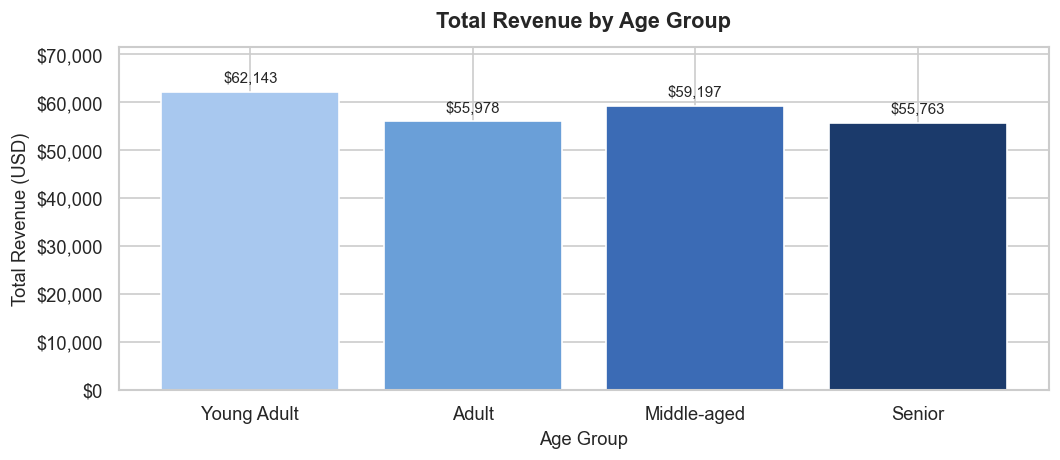

             Total Revenue  Avg Purchase  Transactions
age_group                                             
Young Adult          62143     60.450389          1028
Adult                55978     59.424628           942
Middle-aged          59197     60.037525           986
Senior               55763     59.070975           944


In [19]:
age_rev = df.groupby('age_group', observed=True)['purchase_amount'].agg(['sum','mean','count'])
age_rev.columns = ['Total Revenue', 'Avg Purchase', 'Transactions']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(age_rev.index, age_rev['Total Revenue'],
              color=['#A8C8EF','#6A9FD8','#3B6BB5','#1B3A6B'])
ax.bar_label(bars, labels=[f'${v:,.0f}' for v in age_rev['Total Revenue']], padding=4, fontsize=9)
ax.set_title('Total Revenue by Age Group', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Total Revenue (USD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylim(0, age_rev['Total Revenue'].max() * 1.15)
plt.tight_layout()
plt.savefig('charts/revenue_by_age_group.png', bbox_inches='tight')
plt.show()
print(age_rev)

### 3.6 Purchase Frequency Distribution

In [ ]:
freq_order = ['Weekly', 'Fortnightly', 'Bi-Weekly', 'Monthly',
              'Quarterly', 'Every 3 Months', 'Annually']
freq = df['frequency_of_purchases'].value_counts().reindex(freq_order).dropna()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(freq.index, freq.values, color='#1B3A6B')
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title('Customer Purchase Frequency', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Customers', fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('charts/purchase_frequency.png', bbox_inches='tight')
plt.show()

## 4. SQL Analytics

The cleaned dataset was loaded into a PostgreSQL database (`customer_behaviour`) using SQLAlchemy. The following queries replicate key business analyses in SQL.

In [14]:
# ── SQL Query 1: Total revenue by gender ──────────────────────────────────
# SELECT gender,
#        COUNT(*) AS total_customers,
#        SUM(purchase_amount) AS total_revenue,
#        ROUND(AVG(purchase_amount), 2) AS avg_purchase
# FROM customer
# GROUP BY gender
# ORDER BY total_revenue DESC;

# Python equivalent:
result = df.groupby('gender').agg(
    total_customers=('customer_id', 'count'),
    total_revenue=('purchase_amount', 'sum'),
    avg_purchase=('purchase_amount', 'mean')
).round(2)
print('Revenue by Gender:')
print(result)

Revenue by Gender:
        total_customers  total_revenue  avg_purchase
gender                                              
Female             1248          75191         60.25
Male               2652         157890         59.54


In [15]:
# ── SQL Query 2: Customers who used discount but spent above average ───────
# SELECT customer_id, gender, purchase_amount, category
# FROM customer
# WHERE discount_applied = 'Yes'
#   AND purchase_amount > (SELECT AVG(purchase_amount) FROM customer)
# ORDER BY purchase_amount DESC
# LIMIT 10;

avg_spend = df['purchase_amount'].mean()
high_disc = df[(df['discount_applied'] == 'Yes') & (df['purchase_amount'] > avg_spend)]
print(f'Average purchase: ${avg_spend:.2f}')
print(f'Customers using discount AND spending above average: {len(high_disc)}')
print(high_disc[['customer_id','gender','purchase_amount','category']].sort_values('purchase_amount', ascending=False).head(10))

Average purchase: $59.76
Customers using discount AND spending above average: 839
      customer_id gender  purchase_amount     category
42             43   Male              100    Outerwear
95             96   Male              100     Footwear
769           770   Male              100     Clothing
861           862   Male              100     Clothing
243           244   Male              100  Accessories
204           205   Male              100     Footwear
1405         1406   Male              100     Clothing
1412         1413   Male              100     Clothing
1421         1422   Male              100     Clothing
1456         1457   Male              100    Outerwear


In [16]:
# ── SQL Query 3: Revenue by category and season (cross-tab) ───────────────
# SELECT category, season,
#        SUM(purchase_amount) AS total_revenue,
#        ROUND(AVG(purchase_amount), 2) AS avg_purchase
# FROM customer
# GROUP BY category, season
# ORDER BY category, total_revenue DESC;

pivot = df.pivot_table(values='purchase_amount', index='category',
                       columns='season', aggfunc='sum').round(0)
print('Revenue by Category x Season:')
print(pivot)

Revenue by Category x Season:
season        Fall  Spring  Summer  Winter
category                                  
Accessories  19874   17007   19028   18291
Clothing     26220   27692   23078   27274
Footwear      8665    9555    9393    8480
Outerwear     5259    4425    4278    4562


In [17]:
# ── SQL Query 4: Top 10 highest spending customers ─────────────────────────
# SELECT customer_id, gender, age, category,
#        SUM(purchase_amount) AS total_spend,
#        COUNT(*) AS transactions
# FROM customer
# GROUP BY customer_id, gender, age, category
# ORDER BY total_spend DESC
# LIMIT 10;

top_customers = df.groupby(['customer_id','gender','age','category']).agg(
    total_spend=('purchase_amount','sum'),
    transactions=('purchase_amount','count')
).sort_values('total_spend', ascending=False).head(10)
print('Top 10 Customers by Spend:')
print(top_customers)

Top 10 Customers by Spend:
                                  total_spend  transactions
customer_id gender age category                            
1480        Male   48  Outerwear          100             1
1457        Male   59  Outerwear          100             1
1592        Male   18  Clothing           100             1
2072        Male   69  Outerwear          100             1
1422        Male   68  Clothing           100             1
1413        Male   25  Clothing           100             1
1406        Male   33  Clothing           100             1
1848        Male   46  Footwear           100             1
770         Male   52  Clothing           100             1
2843        Female 28  Outerwear          100             1


In [18]:
# ── SQL Query 5: Subscription vs non-subscription revenue comparison ───────
# SELECT subscription_status,
#        COUNT(*) AS customers,
#        SUM(purchase_amount) AS total_revenue,
#        ROUND(AVG(purchase_amount), 2) AS avg_purchase,
#        ROUND(AVG(previous_purchases), 1) AS avg_prev_purchases
# FROM customer
# GROUP BY subscription_status;

sub = df.groupby('subscription_status').agg(
    customers=('customer_id','count'),
    total_revenue=('purchase_amount','sum'),
    avg_purchase=('purchase_amount','mean'),
    avg_prev_purchases=('previous_purchases','mean')
).round(2)
print('Subscriber vs Non-Subscriber Analysis:')
print(sub)

Subscriber vs Non-Subscriber Analysis:
                     customers  total_revenue  avg_purchase  \
subscription_status                                           
No                        2847         170436         59.87   
Yes                       1053          62645         59.49   

                     avg_prev_purchases  
subscription_status                      
No                                25.08  
Yes                               26.08  


## 5. Key Business Insights

| # | Insight | Implication |
|---|---------|-------------|
| 1 | **Clothing drives 44.7% of revenue** ($104,264) | Prioritise clothing inventory and promotions |
| 2 | **Fall is the highest-value season** — avg purchase $61.56 vs $58.41 in Summer | Focus marketing spend on Fall campaigns |
| 3 | **Discounts reduce average spend** ($59.28 vs $60.13 without discount) | Discounts are not increasing basket size — reconsider discount strategy |
| 4 | **Female customers spend more per transaction** ($60.25 vs $59.54) despite lower volume | Opportunity to grow female customer base to increase revenue |
| 5 | **Subscribers are fewer (27%) but loyal** — similar avg purchase, lower previous purchases | Focus on converting non-subscribers to subscription to improve retention |

---
*Analysis by Pooja Katrodiya | Tools: Python, Pandas, Matplotlib, Seaborn, PostgreSQL*